# D15 · Intervals, Bayesian updating, and meaningful effects

<!-- paper-first -->
### Research question

**Reading:** [PD01](../../curriculum/papers/design.md#pd01). Review the assigned figure or result before starting the lesson.

**Question:** Would a thresholded decision, an interval, and a posterior probability answer the same question?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

A p value, a confidence interval, and a Bayesian posterior answer different questions. A frequentist interval is produced by a procedure with stated repeated-sampling coverage under assumptions. A Bayesian credible interval contains a stated posterior probability conditional on the likelihood, prior, and model. Neither phrase should be silently substituted for the other. A posterior can support a probability statement about an effect, but that statement inherits the model and prior assumptions.

For an inspectable Bayesian example we treat an estimated mean as normally distributed with known standard error. The prior for the unknown effect is also normal. Posterior precision is prior precision plus data precision. The posterior mean is their precision-weighted average. This conjugate calculation exposes the transformation: prior and likelihood → posterior. It does not require a neural network or sampling algorithm, and it provides a check for more complicated software.

A narrow zero-centered prior pulls a noisy positive estimate toward zero. A wide prior produces a posterior close to the likelihood-based estimate. A highly informative prior is not automatically more objective; its information needs justification, ideally from independent evidence and sensitivity analysis. Posterior probability above zero is not a frequentist p value and does not give the probability of an exact point null under a continuous prior. Comparing model hypotheses with a point mass requires a different specification.

Scientific importance adds another layer. Failure to reject zero does not prove that an effect is negligibly small. Conversely, a precisely estimated tiny effect can be statistically distinguishable from zero but unimportant for the research aim. Define a smallest effect of interest in outcome units before analysis. In a simple known-variance normal test, a 90% confidence interval wholly inside prespecified equivalence bounds corresponds to two one-sided tests at alpha=.05. We demonstrate a case consistent with zero yet sufficiently precise to support equivalence within a chosen margin. The margin is a substantive choice, not something selected to fit the observed interval.

Predict which prior causes more shrinkage. Report posterior assumptions before interpreting probabilities.

Prior SD / posterior mean / SD / P(effect>0): [[ 0.2         0.1         0.17888544  0.71192494]
 [ 1.          0.43103448  0.37139068  0.87709686]
 [10.          0.49920128  0.39968038  0.89416768]]


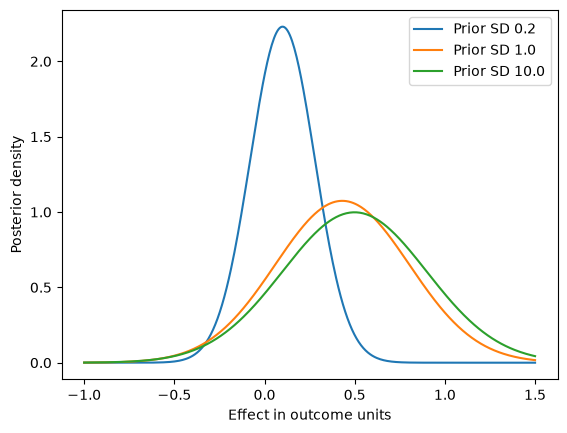

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
estimate,se=.5,.4
prior_mean=0.;prior_sd=np.array([.2,1.,10.])
post_var=1/(1/prior_sd**2+1/se**2)
post_mean=post_var*(prior_mean/prior_sd**2+estimate/se**2)
post_sd=np.sqrt(post_var)
prob_positive=stats.norm.sf(0,loc=post_mean,scale=post_sd)
assert np.all(np.diff(post_mean)>0)
assert np.all(post_sd<se)
assert abs(post_mean[-1]-estimate)<.001
print('Prior SD / posterior mean / SD / P(effect>0):',np.c_[prior_sd,post_mean,post_sd,prob_positive])
x=np.linspace(-1,1.5,400)
for mean,sd,p_sd in zip(post_mean,post_sd,prior_sd):
    plt.plot(x,stats.norm.pdf(x,mean,sd),label=f'Prior SD {p_sd}')
plt.xlabel('Effect in outcome units');plt.ylabel('Posterior density');plt.legend();plt.show()

A separate precise estimate can fail a zero-effect test and satisfy an equivalence criterion. Keep these data separate from the Bayesian example.

In [2]:
equiv_estimate,equiv_se,margin=.05,.04,.2
ci95=equiv_estimate+np.array([-1,1])*stats.norm.ppf(.975)*equiv_se
ci90=equiv_estimate+np.array([-1,1])*stats.norm.ppf(.95)*equiv_se
p_zero=2*stats.norm.sf(abs(equiv_estimate/equiv_se))
p_lower=stats.norm.sf((equiv_estimate+margin)/equiv_se)
p_upper=stats.norm.cdf((equiv_estimate-margin)/equiv_se)
assert ci95[0]<0<ci95[1] and p_zero>.05
assert ci90[0]>-margin and ci90[1]<margin
assert max(p_lower,p_upper)<.05
print('95% CI / 90% CI / zero-test p / TOST p:',ci95,ci90,p_zero,max(p_lower,p_upper))

95% CI / 90% CI / zero-test p / TOST p: [-0.02839856  0.12839856] [-0.01579415  0.11579415] 0.2112995473337107 8.841728520080361e-05


## Supervise the AI, then transfer the idea

**AI prompt:** “Explain the prior, likelihood, posterior, confidence coverage, and equivalence bounds separately. Show the precision-weighted normal update in at most 15 lines. Ask me why probability above zero is not a point-null probability. Keep the two teaching examples' assumptions separate.”

**Deliberate mistake:** claim p>.05 proves no effect, or select equivalence bounds after seeing the interval. Repair the statement with the effect estimate, uncertainty, and prespecified meaningful range. For actual neuroimaging, specify units, prior predictive checks, sensitivity to priors, temporal and hierarchical likelihood assumptions, and the multiple-testing or decision context. A posterior map does not by itself solve spatial selection or model misspecification. Deliver two valid interval interpretations and explain how they differ without declaring one universally superior.

## Answer key — read after your own explanation

The tighter zero-centered prior produces greater shrinkage and smaller posterior SD. The very broad prior approaches the likelihood estimate .5. The separate estimate .05 with SE .04 has a 95% interval containing zero, yet its 90% interval lies inside ±.2; this supports equivalence under the stated normal model and margins. A continuous prior assigns zero probability to an exact point, so P(effect>0) cannot be interpreted as one minus a point-null probability.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [MIT 9.07 syllabus, Bayesian methods, confidence intervals, likelihood, and testing](https://ocw.mit.edu/courses/9-07-statistics-for-brain-and-cognitive-science-fall-2016/pages/syllabus/); [Poldrack BayesianInference notebook](https://github.com/poldrack/fmri-analysis-vm/blob/d93fcf8e818c850d0a1b4e96b01ac987f27e9d34/analysis/Bayesian/BayesianInference.ipynb) is linked rather than vendored because it explicitly borrows material with additional provenance; this conjugate example is newly written. See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Revisit [PD01](../../curriculum/papers/design.md#pd01) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
